# Experiment 3: Regression on Loan Amounts

Linear, Ridge, Lasso and Elastic Net regression on the loan prediction dataset.

In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Helper functions

In [3]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return dict(MAE=mae, MSE=mse, RMSE=np.sqrt(mse), R2=r2_score(y_true, y_pred))

def train_and_evaluate_regressor(model, param_grid, X_train, y_train, X_test, y_test, cv, name):
    t0 = time.perf_counter()
    if param_grid:
        grid = GridSearchCV(model, param_grid, cv=cv, scoring="r2", n_jobs=1)
        grid.fit(X_train, y_train)
        best_estimator = grid.best_estimator_
        best_params = grid.best_params_
        best_cv_score = grid.best_score_
    else:
        best_estimator = model.fit(X_train, y_train)
        best_params = None
        best_cv_score = None
    train_time = time.perf_counter() - t0

    y_pred = best_estimator.predict(X_test)
    metrics = evaluate(y_test, y_pred)

    return dict(name=name, model=best_estimator, y_pred=y_pred, train_time=train_time,
                best_params=best_params, best_cv_score=best_cv_score, metrics=metrics)

def build_eda_summary_figure(df):
    fig, axes = plt.subplots(4, 3, figsize=(20, 22))
    axes = axes.flatten()

    def _bar(ax, counts, title, xlabel):
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax,
                    hue=counts.index.astype(str), palette="crest", legend=False)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    sns.histplot(df["LoanAmount"], bins=30, kde=True, color="teal", ax=axes[0])
    axes[0].set_title("(1) LoanAmount Distribution (Target)")
    axes[0].set_xlabel("Loan Amount (thousands)")
    axes[0].set_ylabel("Frequency")

    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
    _bar(axes[1], missing_counts, "(2) Missing Values per Column (Raw)", "Column")

    axes[2].scatter(df["ApplicantIncome"], df["LoanAmount"], alpha=0.5, s=15, color="steelblue")
    axes[2].set_title("(3) Applicant Income vs Loan Amount")
    axes[2].set_xlabel("Applicant Income")
    axes[2].set_ylabel("Loan Amount")

    axes[3].scatter(df["CoapplicantIncome"], df["LoanAmount"], alpha=0.5, s=15, color="darkorange")
    axes[3].set_title("(4) Co-applicant Income vs Loan Amount")
    axes[3].set_xlabel("Co-applicant Income")
    axes[3].set_ylabel("Loan Amount")

    ch = df["Credit_History"].apply(lambda v: "Missing" if pd.isna(v) else str(int(v)))
    _bar(axes[4], ch.value_counts(), "(5) Credit History Counts", "Credit History")

    _bar(axes[5], df["Property_Area"].value_counts(), "(6) Property Area Counts", "Property Area")

    _bar(axes[6], df["Education"].value_counts(), "(7) Education Counts", "Education")

    se = df["Self_Employed"].fillna("Missing")
    _bar(axes[7], se.value_counts(), "(8) Self Employed Counts", "Self Employed")

    mar = df["Married"].fillna("Missing")
    _bar(axes[8], mar.value_counts(), "(9) Married Counts", "Married")

    dep = df["Dependents"].fillna("Missing")
    dep_counts = dep.value_counts()
    order = [d for d in ["0", "1", "2", "3+", "Missing"] if d in dep_counts.index]
    dep_counts = dep_counts.reindex(order)
    _bar(axes[9], dep_counts, "(10) Dependents Counts", "Dependents")

    sns.boxplot(x="Education", y="LoanAmount", data=df, ax=axes[10],
                hue="Education", palette="Set2", legend=False)
    axes[10].set_title("(11) Loan Amount by Education")
    axes[10].set_xlabel("Education")
    axes[10].set_ylabel("Loan Amount")

    numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "Loan_Amount_Term",
                     "Credit_History", "LoanAmount"]
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[11],
                cbar_kws={"shrink": 0.8}, square=True, annot_kws={"size": 11})
    axes[11].set_title("(12) Numeric Feature Correlation")
    axes[11].tick_params(axis="x", rotation=25)
    axes[11].tick_params(axis="y", rotation=0)
    axes[11].set_xlabel("")
    axes[11].set_ylabel("")

    fig.suptitle("Loan Prediction Dataset - Consolidated EDA Summary",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

## Load the data

Raw shape: (614, 11)
Missing values before cleaning:
 Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


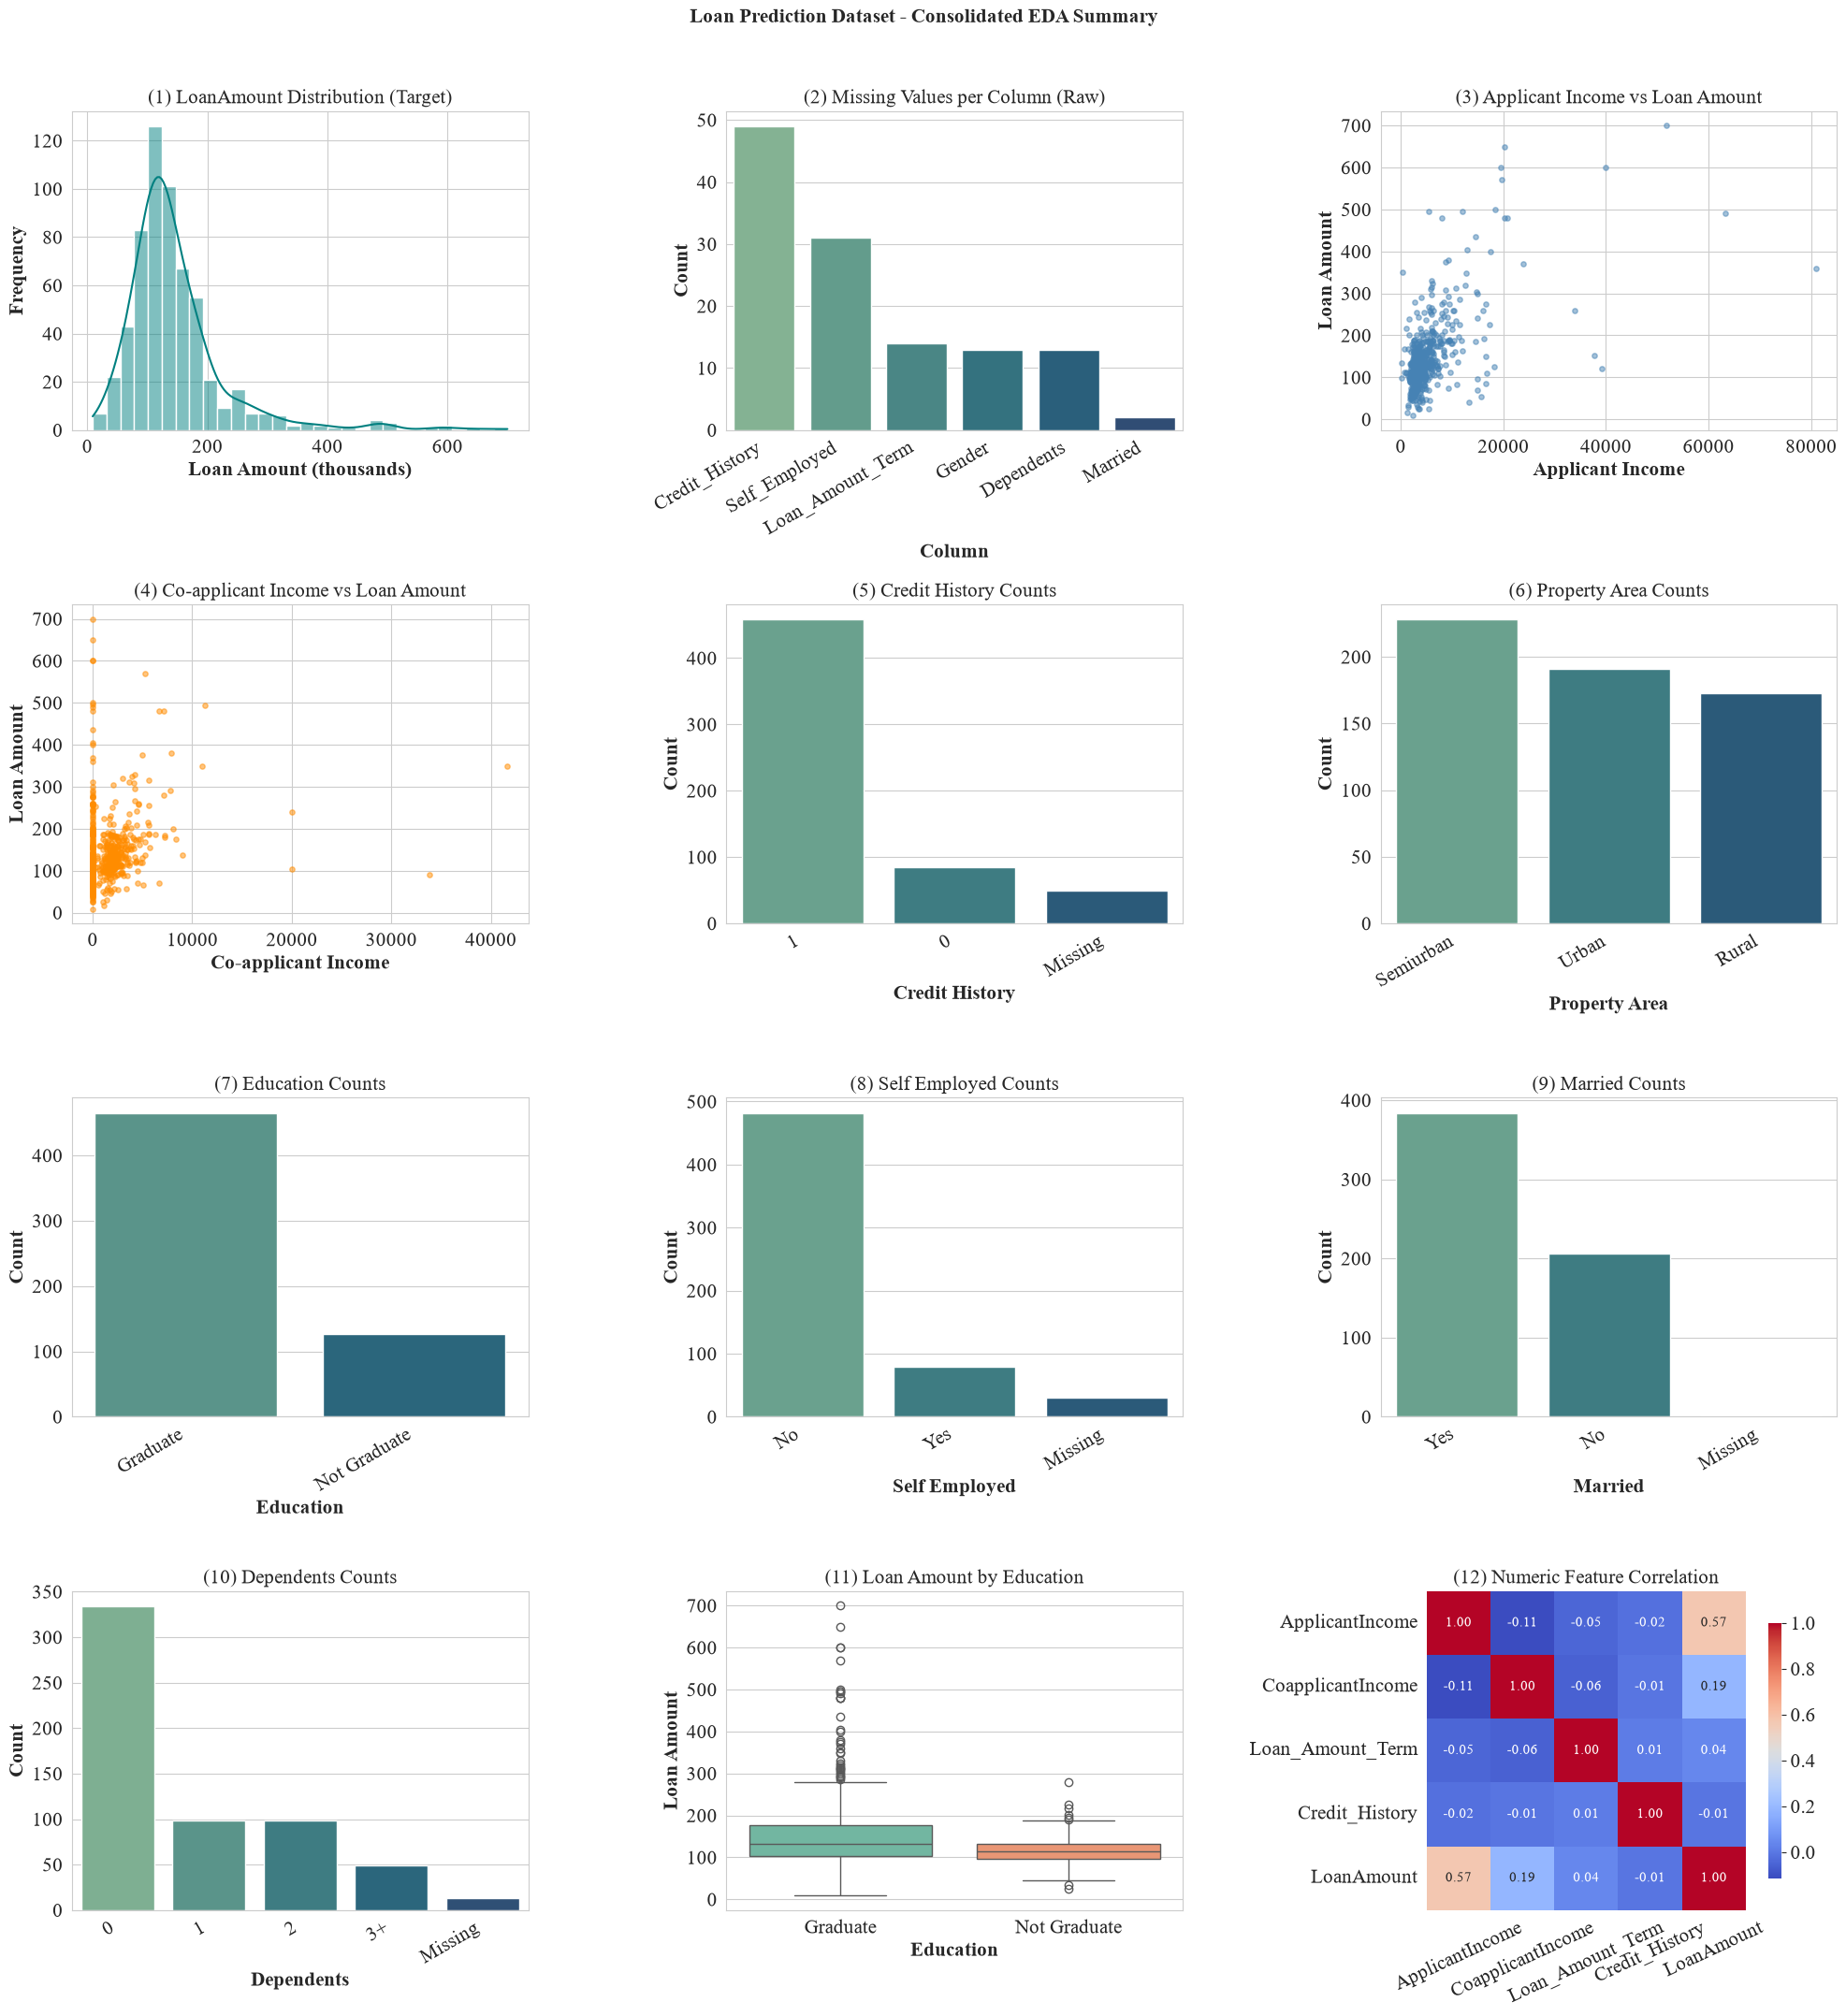

Saved consolidated EDA summary figure -> figures/00_eda_summary.eps (600 DPI) and .png (150 DPI)


In [4]:
df = pd.read_csv("loan_train.csv")
df = df.drop(columns=["Loan_ID", "Loan_Status"])
print("Raw shape:", df.shape)
print("Missing values before cleaning:\n", df.isnull().sum())

df = df.dropna(subset=["LoanAmount"]).reset_index(drop=True)

df_raw_eda = df.copy()
eda_fig = build_eda_summary_figure(df_raw_eda)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)
print("Saved consolidated EDA summary figure -> figures/00_eda_summary.eps (600 DPI) and .png (150 DPI)")

## Preprocessing


Missing values after cleaning:
 0


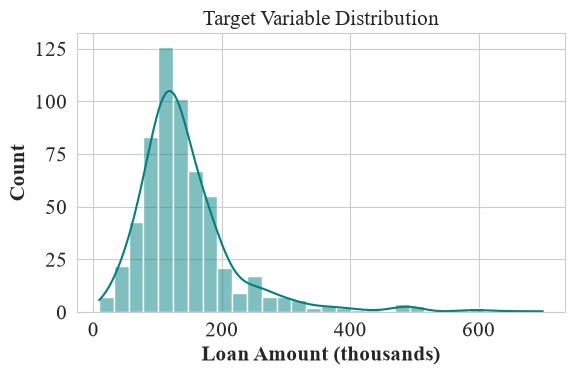

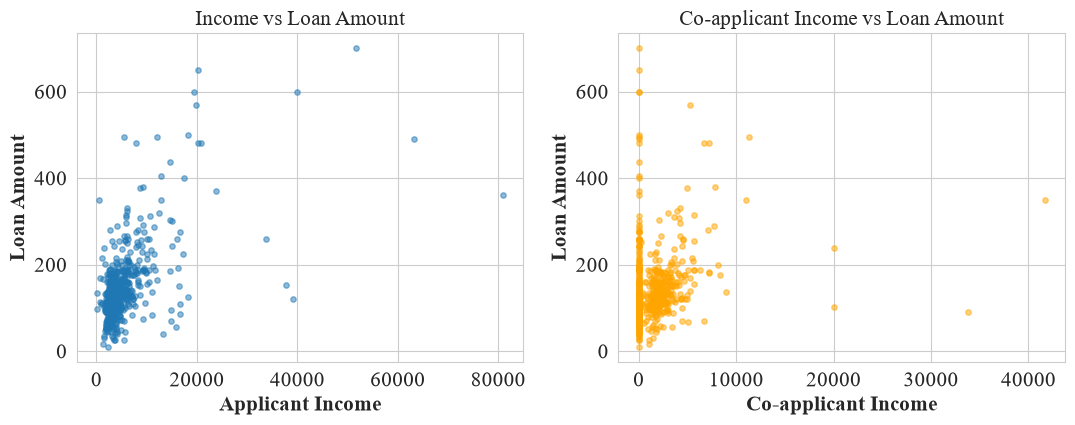

In [5]:
cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
num_cols = ["ApplicantIncome", "CoapplicantIncome", "Loan_Amount_Term", "Credit_History"]

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

df["Dependents"] = df["Dependents"].replace("3+", "3").astype(int)

print("\nMissing values after cleaning:\n", df.isnull().sum().sum())

df_enc = pd.get_dummies(df, columns=["Gender","Married","Education","Self_Employed","Property_Area"], drop_first=True)

y = df_enc["LoanAmount"].values
X = df_enc.drop(columns=["LoanAmount"])
feature_names = X.columns.tolist()
X = X.values.astype(float)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RNG)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

plt.figure(figsize=(6,4))
sns.histplot(y, bins=30, kde=True, color="teal")
plt.xlabel("Loan Amount (thousands)"); plt.title("Target Variable Distribution")
plt.tight_layout(); plt.savefig("figures/01_target_distribution.png", dpi=150); plt.show()
plt.close()

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
axes[0].scatter(df["ApplicantIncome"], y, alpha=0.5, s=15)
axes[0].set_xlabel("Applicant Income"); axes[0].set_ylabel("Loan Amount")
axes[0].set_title("Income vs Loan Amount")
axes[1].scatter(df["CoapplicantIncome"], y, alpha=0.5, s=15, color="orange")
axes[1].set_xlabel("Co-applicant Income"); axes[1].set_ylabel("Loan Amount")
axes[1].set_title("Co-applicant Income vs Loan Amount")
plt.tight_layout(); plt.savefig("figures/02_feature_vs_target.png", dpi=150); plt.show()
plt.close()

## Train the models

In [6]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=RNG)

lin_result = train_and_evaluate_regressor(
    LinearRegression(), None, X_train, y_train, X_test, y_test, kf5, "Linear Regression")

ridge_result = train_and_evaluate_regressor(
    Ridge(random_state=RNG), {"alpha": [0.01, 0.1, 1, 10, 100]},
    X_train, y_train, X_test, y_test, kf5, "Ridge Regression")
print("Ridge best alpha:", ridge_result["best_params"], "CV R2:", ridge_result["best_cv_score"])

lasso_result = train_and_evaluate_regressor(
    Lasso(random_state=RNG, max_iter=10000), {"alpha": [0.001, 0.01, 0.1, 1, 10]},
    X_train, y_train, X_test, y_test, kf5, "Lasso Regression")
print("Lasso best alpha:", lasso_result["best_params"], "CV R2:", lasso_result["best_cv_score"])

enet_result = train_and_evaluate_regressor(
    ElasticNet(random_state=RNG, max_iter=10000),
    {"alpha": [0.01, 0.1, 1, 10], "l1_ratio": [0.2, 0.5, 0.8]},
    X_train, y_train, X_test, y_test, kf5, "Elastic Net Regression")
print("ElasticNet best params:", enet_result["best_params"], "CV R2:", enet_result["best_cv_score"])

model_results = [lin_result, ridge_result, lasso_result, enet_result]
results_test = {r["name"]: r["metrics"] for r in model_results}
train_times = {r["name"]: r["train_time"] for r in model_results}
models_fitted = {r["name"]: r["model"] for r in model_results}

lin = models_fitted["Linear Regression"]
ridge_best = models_fitted["Ridge Regression"]
lasso_best = models_fitted["Lasso Regression"]
enet_best = models_fitted["Elastic Net Regression"]

Ridge best alpha: {'alpha': 100} CV R2: 0.3713833610437718
Lasso best alpha: {'alpha': 10} CV R2: 0.33108022245796487
ElasticNet best params: {'alpha': 1, 'l1_ratio': 0.8} CV R2: 0.3709564807529404


## Cross-validation

In [7]:
results_cv = {}
scoring = {"MAE":"neg_mean_absolute_error", "MSE":"neg_mean_squared_error", "R2":"r2"}
for name, model in models_fitted.items():
    cvres = cross_validate(model, X_train, y_train, cv=kf5, scoring=scoring)
    results_cv[name] = dict(
        MAE = -cvres["test_MAE"].mean(),
        MSE = -cvres["test_MSE"].mean(),
        RMSE = np.sqrt(-cvres["test_MSE"].mean()),
        R2 = cvres["test_R2"].mean()
    )

## Plots

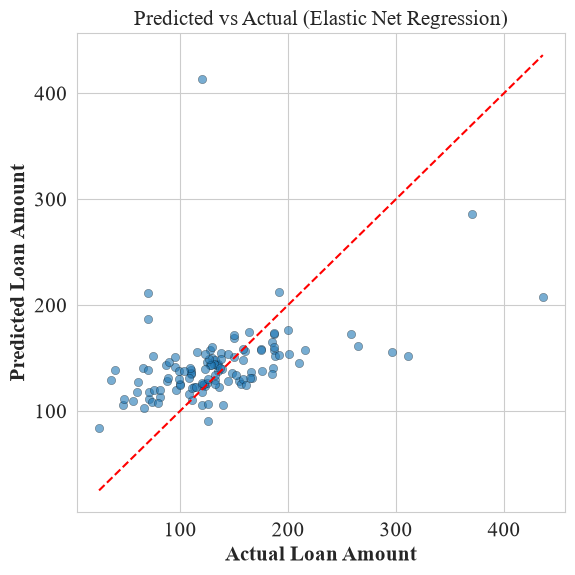

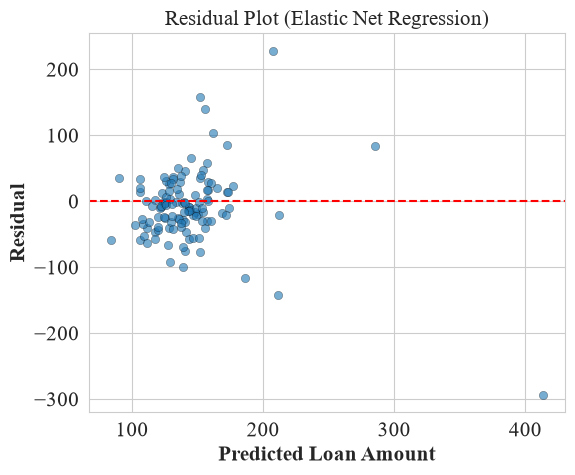

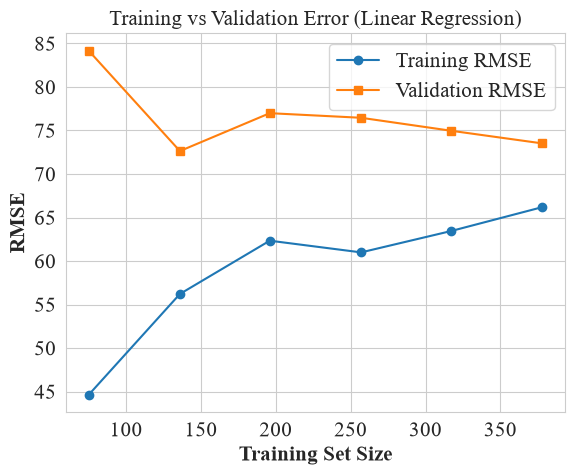

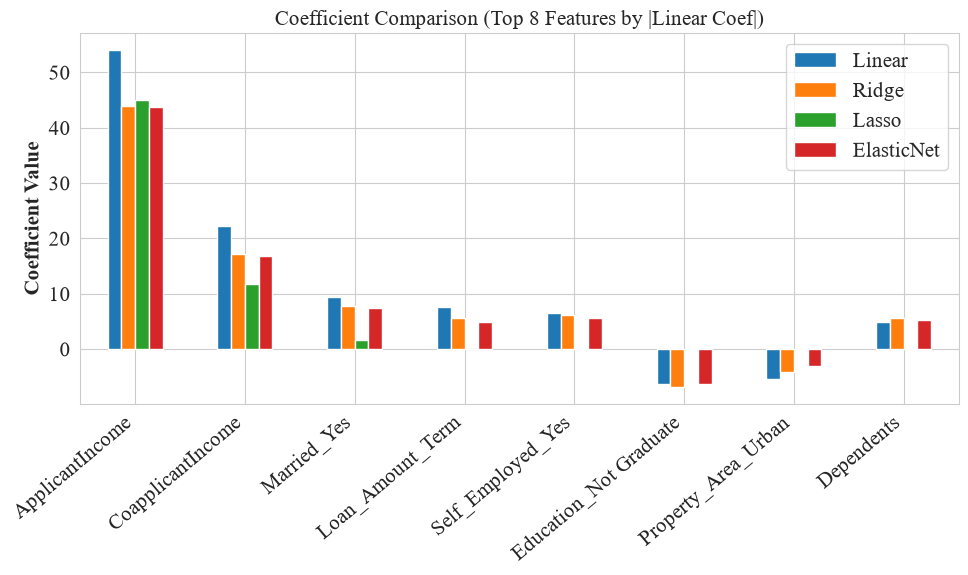

<Figure size 800x500 with 0 Axes>

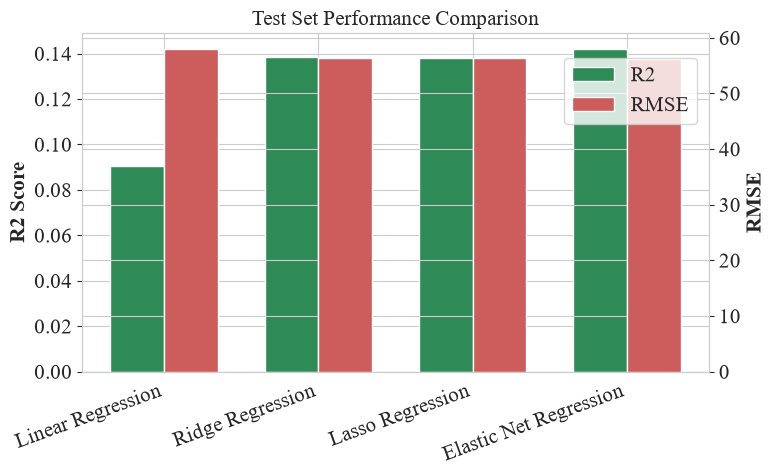

In [8]:
best_name = min(results_test, key=lambda k: results_test[k]["RMSE"])
best_model = models_fitted[best_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.6, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", lw=1.5)
plt.xlabel("Actual Loan Amount"); plt.ylabel("Predicted Loan Amount")
plt.title(f"Predicted vs Actual ({best_name})")
plt.tight_layout(); plt.savefig("figures/03_predicted_vs_actual.png", dpi=150); plt.show()
plt.close()

residuals = y_test - best_pred
plt.figure(figsize=(6,5))
plt.scatter(best_pred, residuals, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Loan Amount"); plt.ylabel("Residual")
plt.title(f"Residual Plot ({best_name})")
plt.tight_layout(); plt.savefig("figures/04_residual_plot.png", dpi=150); plt.show()
plt.close()

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train, y_train, cv=kf5,
    train_sizes=np.linspace(0.2,1.0,6), scoring="neg_mean_squared_error")
train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse = np.sqrt(-val_scores).mean(axis=1)
plt.figure(figsize=(6,5))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="s", label="Validation RMSE")
plt.xlabel("Training Set Size"); plt.ylabel("RMSE")
plt.title("Training vs Validation Error (Linear Regression)")
plt.legend(); plt.tight_layout(); plt.savefig("figures/05_train_val_error.png", dpi=150); plt.show()
plt.close()

coef_df = pd.DataFrame({
    "Linear": lin.coef_,
    "Ridge": ridge_best.coef_,
    "Lasso": lasso_best.coef_,
    "ElasticNet": enet_best.coef_,
}, index=feature_names)
top_idx = coef_df["Linear"].abs().sort_values(ascending=False).head(8).index
plt.figure(figsize=(10,6))
coef_df.loc[top_idx].plot(kind="bar", ax=plt.gca())
plt.ylabel("Coefficient Value"); plt.title("Coefficient Comparison (Top 8 Features by |Linear Coef|)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout(); plt.savefig("figures/06_coefficient_comparison.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(8,5))
names = list(results_test.keys())
r2s = [results_test[n]["R2"] for n in names]
rmses = [results_test[n]["RMSE"] for n in names]
x = np.arange(len(names)); w=0.35
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(x-w/2, r2s, width=w, label="R2", color="seagreen")
ax1.set_ylabel("R2 Score")
ax2 = ax1.twinx()
ax2.bar(x+w/2, rmses, width=w, label="RMSE", color="indianred")
ax2.set_ylabel("RMSE")
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha="right")
plt.title("Test Set Performance Comparison")
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.tight_layout(); plt.savefig("figures/07_test_performance_comparison.png", dpi=150); plt.show()
plt.close()

## Save results

In [9]:
with open("results_summary.txt","w") as f:
    f.write(f"Cleaned dataset shape: {df_enc.shape}\n")
    f.write(f"Features used ({len(feature_names)}): {feature_names}\n\n")

    f.write(f"Ridge best alpha: {ridge_result['best_params']}  CV R2: {ridge_result['best_cv_score']:.4f}\n")
    f.write(f"Lasso best alpha: {lasso_result['best_params']}  CV R2: {lasso_result['best_cv_score']:.4f}\n")
    f.write(f"ElasticNet best params: {enet_result['best_params']}  CV R2: {enet_result['best_cv_score']:.4f}\n\n")

    f.write("=== Test Set Performance ===\n")
    for n in names:
        f.write(f"{n}: {results_test[n]}  train_time={train_times[n]:.4f}s\n")

    f.write("\n=== 5-Fold CV Performance (mean) ===\n")
    for n in names:
        f.write(f"{n}: {results_cv[n]}\n")

    f.write(f"\nBest model by test RMSE: {best_name}\n")
    f.write(f"\nCoefficient table (top 8 features):\n{coef_df.loc[top_idx].to_string()}\n")

print("\nDone. Results written to results_summary.txt and figures/ directory.")
print("\n=== TEST RESULTS ===")
for n in names:
    print(n, results_test[n])
print("\n=== CV RESULTS ===")
for n in names:
    print(n, results_cv[n])


Done. Results written to results_summary.txt and figures/ directory.

=== TEST RESULTS ===
Linear Regression {'MAE': 36.52420608730909, 'MSE': 3352.432362088393, 'RMSE': np.float64(57.900193109249585), 'R2': 0.09058946088480013}
Ridge Regression {'MAE': 37.37217074925158, 'MSE': 3175.9466914753684, 'RMSE': np.float64(56.3555382502498), 'R2': 0.13846452934951226}
Lasso Regression {'MAE': 37.79592142165356, 'MSE': 3176.7999686387425, 'RMSE': np.float64(56.36310822371973), 'R2': 0.13823306181747963}
Elastic Net Regression {'MAE': 37.32317882630821, 'MSE': 3163.588511442921, 'RMSE': np.float64(56.24578661058018), 'R2': 0.14181691888401415}

=== CV RESULTS ===
Linear Regression {'MAE': np.float64(43.06093460204257), 'MSE': np.float64(5506.902624438634), 'RMSE': np.float64(74.20850776318463), 'R2': np.float64(0.3109981525273783)}
Ridge Regression {'MAE': np.float64(44.068188711762595), 'MSE': np.float64(4932.953166502282), 'RMSE': np.float64(70.23498534564013), 'R2': np.float64(0.3713833610